<center><br><font size=10>HW3</font><br>
<font size=6>Dimensionality Reduction and Model Selection</font>
<br><br>
<b>Introduction to Machine Learning – Digital Sciences for High-Tech</b>
<br><i>Spring 2025</i></center>

# Instructions
1. Write all code within the functions
2. Make sure to **return** the solution in every function
3. Don't be afraid to search the internet for help
4. The answered notebook should be submitted in the following format: HW3_{id}.ipynb
5. **Before submission reset kernel and run all, make sure there are no running errors!!!**
6. When needed to give an answer, don't print it unless you were asked to, just write it at the end of the cell and you should see the output as it is.
7. Do not change variable names or tests. If you are asked to answer with a certain variable, use it and do not use a different name. Do not change the given tests if there are any. You can add new tests as you'd like, but leave the given test in the code as it is.
8. When asked to answer theoretically (without implementing a code), answer in the given markdown "answer here" cell

## Import libraries
You are allowed to use these libraries only.

In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from typing import List, Dict
%matplotlib inline

# Part 1: Dimensionality Reduction

## Load & external data

In this part we shall use the 'crime_data' data set. about this data: [UCI Repository](https://archive.ics.uci.edu/ml/datasets/communities+and+crime#:~:text=UCI%20Machine%20Learning%20Repository%3A%20Communities%20and%20Crime%20Data%20Set&text=Abstract%3A%20Communities%20within%20the%20United,from%20the%201995%20FBI%20UCR.) </br><br>
The following code loads the data, and splits it to train and test for this exercise. </br>
</br>
It also normalizes the data for as follows:</br>
PCA needs each column to have zero mean. In addition, it works better when all features share the same variance (common shoice is 1). the sklearn transformer StandardScaler does exactly that.

In [266]:
# load
data = pd.read_csv("crime_data.csv")
#Converting data to numpy arrays
X, y = data.values[:,:-1], data.values[:, -1]
print(f'X.shape: {X.shape}, y.shape: {y.shape}')

#split to train and test
X_train_raw ,X_test_raw ,y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state= 42, shuffle=True)
print(f'X_train_raw.shape: {X_train_raw.shape}, y_train.shape: {y_train.shape}, \
X_test_raw.shape: {X_test_raw.shape}, y_test.shape: {y_test.shape}')

# normalize to have 0 mean and 1 variance (according to train distribution)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)
print(f'X_train.shape: {X_train.shape}, X_test.shape: {X_test.shape}')

X.shape: (1994, 101), y.shape: (1994,)
X_train_raw.shape: (1595, 101), y_train.shape: (1595,), X_test_raw.shape: (399, 101), y_test.shape: (399,)
X_train.shape: (1595, 101), X_test.shape: (399, 101)


## a. PCA 
 - Implement the function get_principal_components. The function returns the minimal group of components, which explain more than (100*p)% of the variance.
 - Use the next cell to print the number of minimal number of components explaining at least 99% of X_train

In [267]:
# Import Package
from sklearn.decomposition import PCA

In [268]:
def get_principal_components(X: np.array, p: float) -> np.array:
    """
    Returns array of principal components explaining (100*p)% of the variance
    X: 2d numpy array of data we want to apply PCA on. 
    p: float in the range (0,1]. The proportion of variance explained by components
    """
    import numpy as np
from sklearn.decomposition import PCA

def get_principal_components(X: np.array, p: float) -> np.array:
    """
    Returns the minimal group of principal components from X that explain more than 100*p % of the variance.

    Parameters:
    - X: np.array of shape (n_samples, n_features), the input data.
    - p: float, the desired proportion of explained variance (e.g., 0.9 for 90%).

    Returns:
    - np.array of shape (n_samples, k), where k is the minimal number of components that explain > 100*p % of variance.
    """
    return PCA(p).fit(X).components_

In [269]:
components = get_principal_components(X_train,0.99)
print(f'number of components which preserve at least 99% of the variance: {len(components)}')

number of components which preserve at least 99% of the variance: 60


## b. Backward Selection
In this section we will implement a backward selection algorithm, using linear regression and Mallows cp penalization. </br> 
**Reminder:** <br><br>
$ C_p= MSE+2\frac{d+1}{n}\hat{\sigma}^2$ <br><br>
Where : $ \hat{\sigma}^2 = \frac{RSS_{all features}}{n-\#features-1} $,   and $\#features$ is the number of all features

### b1. implement the noise variance estimation
implement the function get_sigma_hat_squared function which retrieves the estimate of sigma_hat_squared. <br>

In [270]:
def get_sigma_hat_squared(X: np.array, y: np.array) -> float: #not the prob
    """
    Returns sigma_hat squared - an estimate of the noise variance sigma
    X: 2d np.array with the data.
    y: labels
    return: float - the sigma hat squared.
    """
    lr_model= LinearRegression().fit(X,y)
    model_rss= np.sum(np.square(y- lr_model.predict(X)))
    return model_rss / (X.shape[0] - X.shape[1] - 1)

### b2. implement the mallows C_p scoring
implement the function get_mallows_cp_score which retrieves the mallows Cp score for linear regression. <br>

In [271]:
def get_mallows_cp_score(X: np.array ,y: np.array, sigma_hat_squared: float) -> float: #not the prob
    """
    Returns mallow cp score for given data, selected features and train model.
    X: 2d numpy array of data with only selected features
    y: 1d numpy array of labels (also knows as target values)
    sigma_hat_squared: the estimate for noise variance
    """
    lr_model= LinearRegression().fit(X,y)
    model_mse= mean_squared_error(y, lr_model.predict(X))
    return model_mse + 2*((X.shape[1]+1)/X.shape[0])*sigma_hat_squared

### b3. Implement comparison function
Create a function that gets as input a list of features and returns the best subset of features, containing one less feature, according to the mallows Cp score.

In [272]:
def remove_feature(X: np.array ,y: np.array ,current_features: List[int] , sigma_hat_squared: float) -> Dict: # not the prob
    """
    Returns dictionary with list of features including the best subset of features and the cp score of the model for that subset.
    X: 2d np array with all the features.
    y: 1d np array with the labels
    current_features: list of indexes which represent the features which are already included
    sigma_hat_squared: the estimate for noise variance
    returns: A dictionary with 2 keys:
            'features': a sorted list of indexes containing the features of the best model  -> current_features - [removed]
            'score': the mallows cp score of that model
    """
    best_score = np.inf
    best_features_lst=current_features
    for i in range(len(current_features)):
        features_subset= current_features[:i] + current_features [i+1:]
        data_subset= X[:,features_subset]
        mlcp_score = get_mallows_cp_score(data_subset, y, sigma_hat_squared)
        if mlcp_score < best_score:
            best_score=mlcp_score
            best_features_lst=features_subset.copy()
    return {'features':sorted(best_features_lst),'score':best_score}

### b4. Backward selection wrapper
No need to implement anything here. When all previous functions are implemented, you should get a nice graph of the mallows C_p score w.r.t the number of features, and print number of features which were chosen. Notice that this could take a few minutes running.

In [273]:
def backward_selection(X: np.array, y: np.array) -> List[int]:
    """
    returns list of indexes for the selected features
    X: 2d numpy array with original training data
    y: numpy vector with targets of training data
    returns: a sorted list containing the indexes of the selected features
    """
    # Calculate error on model with all features
    sigma_hat_squared = get_sigma_hat_squared(X, y)
    # set initial features to all features
    current_features = list(range(X.shape[1]))
    models_lst = []
    #perform backward selection
    while len(current_features) > 1:
        # remove feature
        model = remove_feature(X, y, current_features, sigma_hat_squared)
        #update
        current_features = model['features']
        models_lst.append(model)
    #Plotting
    scores_lst = [x['score'] for x in models_lst]
    plt.plot(range(1,len(scores_lst)+1),scores_lst)
    plt.xlabel("number of features")
    plt.ylabel("Mallows cp")
    plt.title("Mallows Cp score VS number of features")
    plt.show()

    #Returning features of best model, based on mcp score
    best_model = min(models_lst, key = lambda x: x['score'])
    best_features = best_model['features']
    return sorted(best_features)

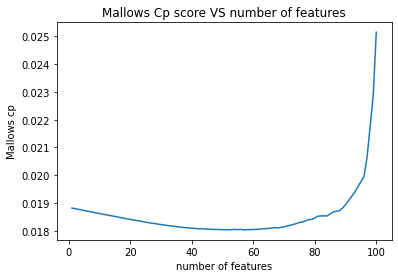

number of selected features by backward: 44


In [274]:
res = backward_selection(X_train,y_train)
print(f'number of selected features by backward: {len(res)}')

## C. Comparison

In the next section, we use the previous results to form new train and test sets

In [275]:
# calculate the test MSE for each reduced dataset
x_backward_reduced_train = X_train[:,res]
x_backward_reduced_test = X_test[:,res]

# get components based on train set:
train_components = get_principal_components(X_train,0.99)
x_pca_train = np.dot(X_train, train_components.T)
x_pca_test = np.dot(X_test, train_components.T)

### C1. Results
Using these new datasets, print the train mse & test mse of each model, and answer the question briefly. <br><br>
To compare between the methods use Linear Regression 

In [276]:
test_mse_backward = mean_squared_error(y_test, LinearRegression().fit(x_backward_reduced_train,y_train).predict(x_backward_reduced_test))
test_mse_pca = mean_squared_error(y_test, LinearRegression().fit(x_pca_train, y_train).predict(x_pca_test))
train_mse_backward =  mean_squared_error(y_train, LinearRegression().fit(x_backward_reduced_train,y_train).predict(x_backward_reduced_train))
train_mse_pca = mean_squared_error(y_train, LinearRegression().fit(x_pca_train, y_train).predict(x_pca_train))

print(f'MSE train - PCA: {round(train_mse_pca,4)}')
print(f'MSE test - PCA: {round(test_mse_pca,4)}')
print(f'MSE train - backward: {round(train_mse_backward,4)}')
print(f'MSE test - backward: {round(test_mse_backward,4)}')

MSE train - PCA: 0.0177
MSE test - PCA: 0.018
MSE train - backward: 0.017
MSE test - backward: 0.0171


### C2. Answer below: 
Based on the results shown above and what you know, which way is better to reduce dimensionality in this case? backward with Mallows Cp, or PCA with 0.99?

We see that the MSE is lower for the backward selection model for both the train and test data, so we will prefer to use backwards with Mallow Cp.

# Part 2

The following code downloads the MNIST data set (one of the most common data set in machine learning).<br>
It contains images of hand written digits in gray scale. The training data contains 60,000 images (6,000 from each digit), and 10,000 test set. Each image is a 28X28 pixel image (total of 784 pixels).<br>
a few examples:<br><br>
<img src="https://storage.googleapis.com/tfds-data/visualization/fig/mnist-3.0.1.png" width="200"/>
<br>In this exercise we shall classify the digits 0 and 8. The following code downloads the data set and splits it to train  and test. The labels are changed to 0 (for 0) and 1 (for 8)

<br>Load the data. You can use the data from the sklearn dataset. If this isn't working, you can read the excel that is given in the moodle, as done in the cell below.

In [277]:
data, labels = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=True)
neg, pos = '0', '8'

C:\Users\yoavr\AppData\Roaming\Python\Python310\site-packages\sklearn\datasets\_openml.py:932: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [278]:
# If the dataset import doesn't work, you can read the data from the excel (lose the comment below)
csv_data = pd.read_csv('mnist.csv', dtype={'class':'category'})
labels = csv_data.iloc[:,-1]
data = csv_data.iloc[:, :-1]

In [279]:
# Take data with 0 or 8 digits only and make labels 0 or 1 accordingly
binary_df = data[(labels==neg)|(labels==pos)]
binary_label = labels[(labels==neg)|(labels==pos)]
binary_label.replace({neg:0,pos:1},inplace=True)

# Convert to numpy array
X_digits = binary_df.values
y_digits = binary_label.astype(int).values

In [280]:
train_and_validation_data,test_data,train_and_validation_labels,test_labels = train_test_split(X_digits,y_digits,
                                                        test_size = 0.25,
                                                        random_state= 42, 
                                                        shuffle=True,
                                                        stratify = y_digits)

#stratify means keeping equal proportions of labels in train and test

In [281]:
# spliting train to - train and validation
train_data,validation_data ,train_labels,validation_labels = train_test_split(train_and_validation_data,train_and_validation_labels,
                                                        test_size = 0.2,
                                                        random_state= 42, 
                                                        shuffle=True)

In [282]:
print('Train dimensions:')
print(f'data: {train_data.shape}')
print(f'labels: {train_labels.shape}')

print('validation dimensions:')
print(f'data: {validation_data.shape}')
print(f'labels: {validation_labels.shape}')

print('Test dimensions:')
print(f'data: {test_data.shape}')
print(f'labels{test_labels.shape}')

Train dimensions:
data: (8236, 784)
labels: (8236,)
validation dimensions:
data: (2060, 784)
labels: (2060,)
Test dimensions:
data: (3432, 784)
labels(3432,)


## To visualize a digit, we can use the following code

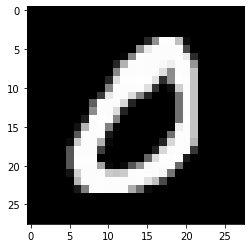

In [283]:
digit = train_and_validation_data[0] #use the scaled data to see what actually is trained on
plt.figure(0)
plt.imshow(digit.reshape(28, 28), cmap=plt.cm.gray)
plt.show()

## 1. LogisticRegression (lr)

1. Run logistic regression on the train data with 'l1' regularization with solver='liblinear', random_state=42. <br> Use the validation data to choose the best regularization parameterr C out of the given list, with respect to accuracy measure.<br> plot the validation accuracy vs the powers array (scale of C) and print the best **Lambda** value: 1/c.

2. Train Logistic regression on the whole data (train+validation).

3. Given that the decision boundary is 0.5, plot the confusion matrix, and print the accuracy of the train data. Use python sns library for plotting the conf matrix.

4. Given that the decision boundary is 0.5, plot the confusion matrix, and print the accuracy of the test data. Use python sns library for plotting the conf matrix.

5. Plot one missclassified 8 digit and one missclassified 0 digit.


Comment: you may use the 'confusion_matrix' imported above from sklearn.metrics (not mandatory)

In [284]:
from sklearn.linear_model import LogisticRegression
powers = range(-10,0)
Cs = [10**p for p in powers] #This is the inverse value for the lambda parameter.
#It bounds the total value of the norm, and directly reduces the hypothesis class

### Choosing the optimal `C`
Reminder: you need to print $\lambda = \frac{1}{c}$

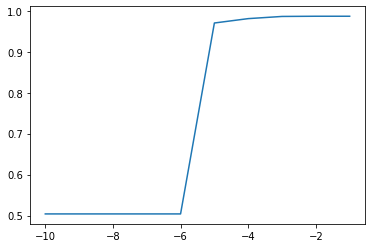

The optimal lambda is:  100.0 
( Best C: 0.01 )


In [285]:
scores = []

for c in Cs:
    log_reg_model = LogisticRegression(penalty="l1",solver = "liblinear",C=c)
    log_reg_model.fit(train_data, train_labels)
    scores.append(log_reg_model.score(validation_data, validation_labels))
    
C_opt_lr = Cs[scores.index(max(scores))]
lambda_opt_lr = 1/C_opt_lr

plt.plot(powers, scores)
plt.show()

print("The optimal lambda is: ", 1/C_opt_lr, "\n( Best C:", C_opt_lr, ")")

### Using the lr best model (the one with the optimal C)

Train confusion Matrix: 
 [[5165   12]
 [  15 5104]]


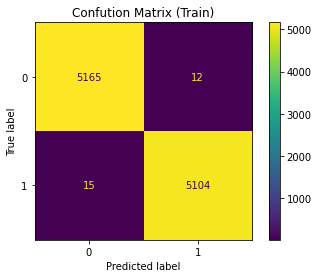

Train Accuracy: 0.9973776223776224
Test confusion Matrix: 
 [[1712   14]
 [  17 1689]]


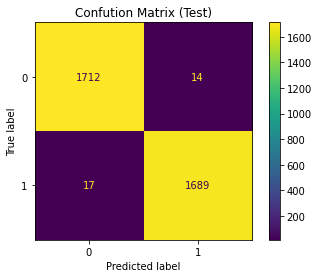

Test Accuracy: 0.990967365967366


In [286]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Train data
train_predictions = log_reg_model.predict(train_and_validation_data)
conf_mat_train = confusion_matrix(train_and_validation_labels, train_predictions)
accuracy_train = accuracy_score(train_and_validation_labels, train_predictions)

print("Train confusion Matrix: \n", conf_mat_train)
display_train = ConfusionMatrixDisplay(confusion_matrix=conf_mat_train, display_labels=[0, 1])
display_train.plot()
plt.title("Confution Matrix (Train)")
plt.show()
print("Train Accuracy:", accuracy_train)

#Test data
conf_mat_test = confusion_matrix(test_labels, test_predictions)
accuracy_test = accuracy_score(test_labels, test_predictions)

print("Test confusion Matrix: \n", conf_mat_test)
display_test = ConfusionMatrixDisplay(confusion_matrix=conf_mat_test,
                                      display_labels=[0, 1])
display_test.plot()
plt.title("Confution Matrix (Test)")
plt.show()
print("Test Accuracy:", accuracy_test)

### plotting 2 missclassified digits

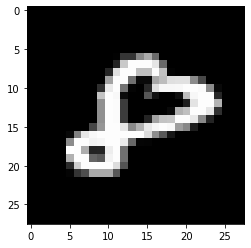

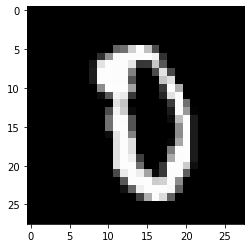

In [287]:
pixel_8 = np.where((test_predictions != test_labels) & (test_labels == 1))[0][0]
plt.imshow(test_data[pixel_8].reshape(28, 28), cmap=plt.cm.gray)
plt.show()

pixel_0 = np.where((test_predictions != test_labels) & (test_labels == 0))[0][0]
plt.imshow(test_data[pixel_0].reshape(28, 28), cmap=plt.cm.gray)
plt.show()

## 2. Multi Layer Perceptron (MLP)

1. Run MLP on the train data with 'l2' regularization (a.k.a ridge regularization) with the following parameters:<br>
   `hidden_layer_sizes=(20,), max_iter=200, solver='sgd', verbose=False, tol=1e-3, random_state=1,
   learning_rate_init=.005, alpha=?????`<br>
   The alpha parameter is the 'l2' coefficient (regularization strength).<br>
   * Check the alpha values between 1, 10, 100, 1000 and 10000. Use the validation data to choose the best one with respect to the accuracy measure.<br>
   * plot the validation accuracy vs alpha values (use log scale if needed)
   * Save the best alpha in the variable: alpha_opt_mlp and print it.

2. Train MLP on the whole data (train+validation).

3. Given that the decision boundary is 0.5, plot the confusion matrix(with sns), and print the accuracy of the train data.

4. Given that the decision boundary is 0.5, plot the confusion matrix(with sns), and print the accuracy of the test data.

5. Plot one missclassified 8 digit and one missclassified 0 digit.

*Comment1*: you may use the 'confusion_matrix' imported above from sklearn.metrics (not mandatory)<br>
*Comment2*: to see the loss convergence between epochs, use verbose=True. Just replace it back to False before submission.

In [288]:
from sklearn.neural_network import MLPClassifier
alphas = [1,10,100,1000,10000]

### Choosing the optimal alpha

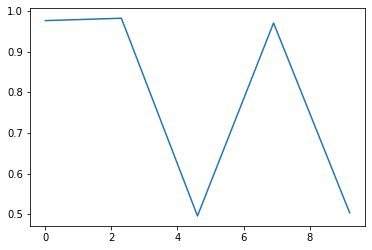

The optimal alpha is:  10


In [289]:
import math

scores=[]

for alpha in alphas:
    model = MLPClassifier(hidden_layer_sizes=(20,), max_iter=200, solver='sgd', verbose=False, tol=1e-3, random_state=1, learning_rate_init=.005, alpha=alpha)
    model.fit(train_data, train_labels)
    model_pred = model.predict(validation_data)
    accuracy=accuracy_score(validation_labels, model_pred)
    scores.append(accuracy)

alpha_opt_mlp = alphas[scores.index(max(scores))]

logs = [math.log(alpha) for alpha in alphas]
plt.plot(logs, scores)
plt.show()
    
print("The optimal alpha is: ", alpha_opt_mlp)

### Using the best MLP model

In [290]:
#TODO: Train on whole data and plot train, test confusion matrices

mlp_model = MLPClassifier(hidden_layer_sizes=(20,), max_iter=200, solver='sgd', verbose=False, tol=1e-3, random_state=1, learning_rate_init=.005, alpha=alpha)
mlp_model.fit(train_and_validation_data,train_and_validation_labels)

mlp_pred = mlp_model.predict(test_data)

### plotting 2 missclassified digits

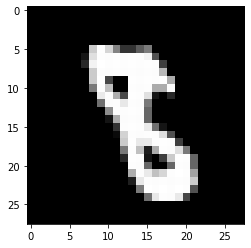

IndexError: index 0 is out of bounds for axis 0 with size 0

In [291]:
pixel_8 = np.where((mlp_pred!=test_labels) & (test_labels == 1))[0][0]
digit = test_data[pixel_8] 
plt.imshow(digit.reshape(28, 28), cmap=plt.cm.gray)
plt.show()

pixel_0 = np.where((mlp_pred!=test_labels) & (test_labels == 0))[0][0]
digit = test_data[pixel_0]
plt.imshow(digit.reshape(28, 28), cmap=plt.cm.gray)
plt.show()